![NVIDIA Logo](images/nvidia.png)

# Exercise: Drop Null Columns

Morpheus ships with many pre-built stages for input, preprocessing, inference, postprocessing, and output.

![prebuilt-stages](images/prebuilt-stages.png)

---

## The Pre-Built Drop Null Stage

One such stage is `morpheus.stages.preprocess.drop_null_stage.DropNullStage` which has been imported for you below. `DropNullStage` expects a `MessageMeta` as input and returns a `MessageMeta`. To use it you specify a column name in the underlying `MessageMeta`'s dataframe for which you would like to filter out any entries in the data that contains null values. For example:

```python
DropNullStage(config, column=column_name_to_drop_null_entries_from)
```

---

## Exercise Objectives

For this exercise you'll again read from the same simple user authentication logs, which as you can see, contains many null values in its `"error_message"` column.

In [1]:
input_file = 'data/simple_user_log.jsonlines'

In [2]:
import cudf
cudf.read_json(input_file, lines=True)

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked


Your objective then is to create a linear pipeline to do the following:

- Read in the user authentication logs.
- Remove any rows containing null values in its `"error_message"` column.
- Store the processed data in an in-memory sink.
- Use the in-memory sink to access the processed dataframe and observe that it has been modified as expected.

---

## Imports

Below are the imports you'll need to complete the exercise.

In [3]:
import logging

from IPython.display import Image

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.preprocess.drop_null_stage import DropNullStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.utils.logger import configure_logging, reset_logging

## Your Work Here

Build and run your pipeline in the space provided below. By all means feel free to create additional code cells for your work, which you can do by clicking the `+` button in the Jupyter menu bar at the top of this notebook.

If you get stuck, a solution is provided below, which you view by expanding the *Solution* section below.

In [4]:
config = Config()
pipeline = LinearPipeline(config)
pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))
pipeline.add_stage(DropNullStage(config, column='error_message'))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.build()

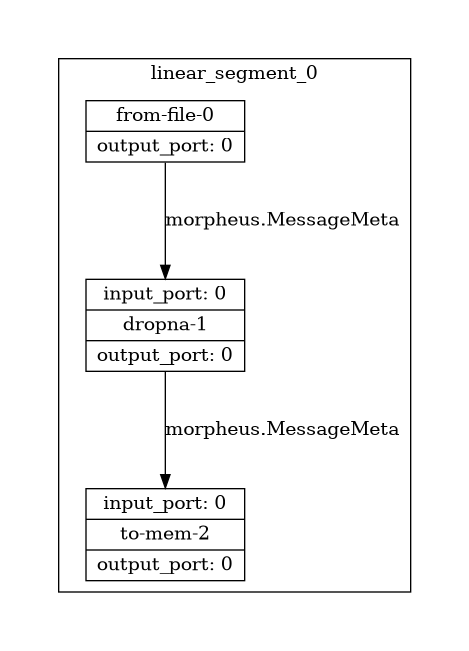

In [5]:
viz_file = './pipeline_visualizations/exercise_drop_null.png'
pipeline.visualize(viz_file)
Image(filename=viz_file)

In [6]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <dropna-1; DropNullStage(column=error_message)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-2; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====


In [7]:
await pipeline.run_async()

In [8]:
in_mem_sink.get_messages()[0].get_data()

,timestamp,user,ip_address,request_time,status,error_message
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked


---

## Solution

In [9]:
df = cudf.read_json('data/simple_user_log.jsonlines', lines=True)

In [10]:
df

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked


In [11]:
config = Config()

In [12]:
pipeline = LinearPipeline(config)

In [13]:
input_file = 'data/simple_user_log.jsonlines'

In [14]:
pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

<from-file-3; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>

In [15]:
pipeline.add_stage(DropNullStage(config, column='error_message'))

<dropna-4; DropNullStage(column=error_message)>

In [16]:
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [17]:
pipeline.build()

In [18]:
viz_file = './pipeline_visualizations/exercise_drop_null.png'
pipeline.visualize(viz_file)

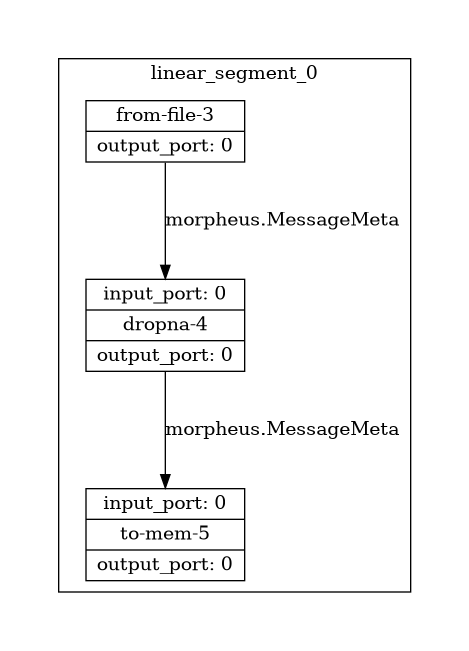

In [19]:
Image(filename=viz_file)

In [20]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

W20250922 07:12:32.955053 140003433170752 logging.cpp:67] MRC logger already initialized


====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-3; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <dropna-4; DropNullStage(column=error_message)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-5; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====


In [21]:
await pipeline.run_async()

In [22]:
messages = in_mem_sink.get_messages()
messages[0].df

,timestamp,user,ip_address,request_time,status,error_message
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked
